In [6]:
import torch
import pandas as pd
import numpy as np
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import matplotlib.pyplot as plt
from matplotlib import gridspec
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)

#define the design: 
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "#f8f8f8",
    "axes.grid": True,
    "grid.color": "white",
    "grid.linewidth": 1.2,
    "font.family": "serif",
})

DATA LOADING AND CLEANING SECTION

In [7]:
"""from google.colab import files
uploaded = files.upload()"""

df = pd.read_csv(r"..\data\properties_with_catchment_features.csv")
df["crime_count_log"] = np.log1p(df["crime_count"])
df["is_ultra_luxury"] = (df["price"] > 10_000_000).astype(int) #this was so helpful in the analysis.
df["price_per_sqft_proxy"] = df["sizeSqFeetMax"] / (df["bedrooms"] + 1)
borough_tier = {
    "Kensington and Chelsea": 1,
    "Westminster": 1,
    "Camden": 2,
    "Hammersmith and Fulham": 2, 
    "Islington": 2,
    "Wandsworth": 3, 
    "Lambeth": 3, 
    "Southwark": 3,
    "Barnet": 3, 
    "Merton": 3
}
df["district"] = df["district"].fillna("Unknown")
df["borough_tier"] = df["district"].map(borough_tier).fillna(4)
rare_types = df["propertyType"].value_counts()
rare_types = rare_types[rare_types < 10].index
df["propertyType"] = df["propertyType"].replace(rare_types, "Other")

#summary for the data: 
print(f"Dataset shape: {df.shape}")
print(f"\nPrice statistics (£):")
print(df["price"].describe().apply(lambda x: f"{x:,.0f}"))
print(f"\nUltra-luxury properties (>£10M): {df['is_ultra_luxury'].sum()} ({df['is_ultra_luxury'].mean()*100:.1f}%)")

Dataset shape: (1019, 32)

Price statistics (£):
count         1,018
mean     11,298,547
std       6,940,021
min         315,000
25%       7,500,000
50%       9,350,000
75%      13,000,000
max      80,000,000
Name: price, dtype: object

Ultra-luxury properties (>£10M): 397 (39.0%)


OUTLIER CHECK

In [8]:
#assess the data quality and outliers:
temp = df.copy()
temp = temp[temp["price"] > 0]
print("After price > 0:", len(temp))

temp = temp[temp["sizeSqFeetMax"] > 0]
print("After size > 0:", len(temp))

price_low = temp["price"].quantile(0.01)
price_high = temp["price"].quantile(0.95)
temp = temp[temp["price"].between(price_low, price_high)]
print("After price filter:", len(temp))

size_high = temp["sizeSqFeetMax"].quantile(0.99)
temp = temp[temp["sizeSqFeetMax"] <= size_high]
print("After size filter:", len(temp))

temp = temp[temp["bedrooms"] <= 20]
print("After bedrooms filter:", len(temp))

temp = temp[temp["bathrooms"] <= 20]
print("After bathrooms filter:", len(temp))

After price > 0: 1018
After size > 0: 1018
After price filter: 958
After size filter: 948
After bedrooms filter: 922
After bathrooms filter: 920


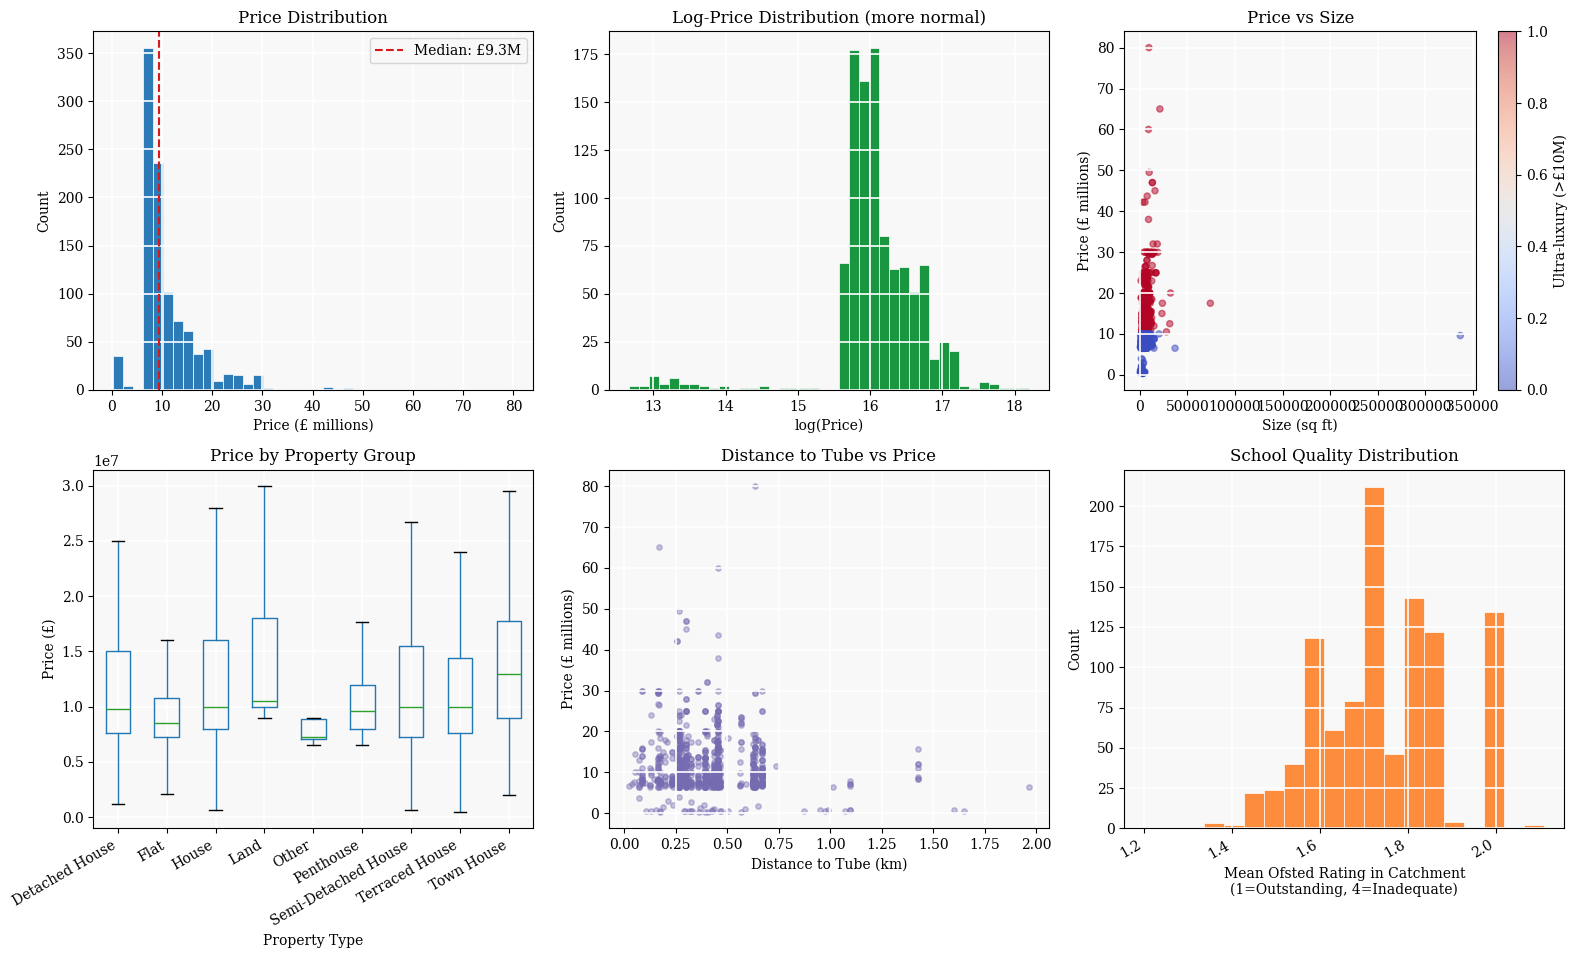

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Exploratory Data Analysis — London Luxury Properties", fontsize=15, fontweight="bold", y=1.01)

ax = axes[0, 0]
ax.hist(df["price"] / 1e6, bins=40, color="#2c7bb6", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Price (£ millions)")
ax.set_ylabel("Count")
ax.set_title("Price Distribution")
ax.axvline(df["price"].median() / 1e6, color="#d7191c", linestyle="--", label=f'Median: £{df["price"].median()/1e6:.1f}M')
ax.legend()

ax = axes[0, 1]
ax.hist(np.log1p(df["price"]), bins=40, color="#1a9641", edgecolor="white", linewidth=0.5)
ax.set_xlabel("log(Price)")
ax.set_ylabel("Count")
ax.set_title("Log-Price Distribution (more normal)")

ax = axes[0, 2]
sc = ax.scatter(df["sizeSqFeetMax"], df["price"] / 1e6,
                c=df["is_ultra_luxury"], cmap="coolwarm", alpha=0.5, s=20)
ax.set_xlabel("Size (sq ft)")
ax.set_ylabel("Price (£ millions)")
ax.set_title("Price vs Size")
plt.xticks(rotation=30, ha="right")
plt.colorbar(sc, ax=ax, label="Ultra-luxury (>£10M)")

ax = axes[1, 0]
df.boxplot(column="price", by="property_group", ax=ax, showfliers=False)
ax.set_xlabel("Property Type")
ax.set_ylabel("Price (£)")
ax.set_title("Price by Property Group")
plt.sca(ax)
plt.xticks(rotation=30, ha="right")
fig.texts = [t for t in fig.texts if "Boxplot" not in t.get_text()]

ax = axes[1, 1]
ax.scatter(df["distance_to_tube"], df["price"] / 1e6,
           alpha=0.4, s=15, color="#756bb1")
ax.set_xlabel("Distance to Tube (km)")
ax.set_ylabel("Price (£ millions)")
ax.set_title("Distance to Tube vs Price")

ax = axes[1, 2]
ax.hist(df["catchment_mean_ofsted"].dropna(), bins=20,
        color="#fd8d3c", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Mean Ofsted Rating in Catchment\n(1=Outstanding, 4=Inadequate)")
ax.set_ylabel("Count")
ax.set_title("School Quality Distribution")

plt.tight_layout()
plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
plt.show()

In [10]:
target_col = "price"

#adding our tests: 
baseline_numeric = [
    "sizeSqFeetMax", "bedrooms", "bathrooms",
    "longitude", "latitude", "distance_to_tube", "crime_count_log"
]
baseline_categorical = ["propertyType", "property_group", "district"]
full_categorical = ["property_group", "propertyType", "district", "ward"]
engineered_numeric = [
    "sizeSqFeetMax", "bedrooms", "bathrooms", "latitude", "longitude",
    "log_sizeSqFeetMax", "sizeSqFeetMax_squared",
    "bedrooms_squared", "bathrooms_squared", "bedrooms_x_bathrooms",
    "bedrooms_per_1000_sqft", "bathrooms_per_1000_sqft",
    "rooms_total", "rooms_per_1000_sqft"
]
catchment_numeric = engineered_numeric + [
    "distance_to_tube", "crime_count_log", "borough_tier",
    "schools_in_catchment", "catchment_mean_ofsted",
    "catchment_best_ofsted", "catchment_has_outstanding",
    "state_primary_in_catchment", "state_primary_best_ofsted",
    "is_ultra_luxury", "price_per_sqft_proxy",
]
numeric_features = [
    "sizeSqFeetMax",
    "bedrooms",
    "bathrooms",
    "latitude",
    "longitude"
]

categorical_features = [
    "property_group"
]

used_columns = numeric_features + categorical_features + [target_col]

data = df[used_columns].copy()

data.head()

,sizeSqFeetMax,bedrooms,bathrooms,latitude,longitude,property_group,price
0,16749.0,8.0,8.0,51.586178,-0.170121,House,24950000.0
1,12960.0,7.0,7.0,51.509539,-0.136100,House,29500000.0
2,6952.0,6.0,6.0,51.498405,-0.146841,Terraced House,25000000.0
3,16749.0,6.0,6.0,51.586178,-0.170121,Detached House,24950000.0
4,10241.0,8.0,10.0,51.535626,-0.181925,Detached House,24950000.0


MODELS

In [11]:
class LinearRegressionModel(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.linear = nn.Linear(input_dim, 1)

    def forward(self, x):
        return self.linear(x)

In [12]:
def remove_outliers(data):
    data = data.copy()

    data = data[data["price"] > 0]
    data = data[data["sizeSqFeetMax"] > 0]

    price_low = data["price"].quantile(0.01)
    price_high = data["price"].quantile(0.95)
    size_high = data["sizeSqFeetMax"].quantile(0.99)

    data = data[
        (data["price"] >= price_low) &
        (data["price"] <= price_high) &
        (data["sizeSqFeetMax"] <= size_high) &
        (data["bedrooms"] <= 10) &
        (data["bathrooms"] <= 10)
    ]

    return data


def add_custom_features(data):
    data = data.copy()

    size = data["sizeSqFeetMax"].replace(0, np.nan)

    data["log_sizeSqFeetMax"] = np.log1p(data["sizeSqFeetMax"])
    data["sizeSqFeetMax_squared"] = data["sizeSqFeetMax"] ** 2

    data["bedrooms_squared"] = data["bedrooms"] ** 2
    data["bathrooms_squared"] = data["bathrooms"] ** 2

    data["bedrooms_x_bathrooms"] = data["bedrooms"] * data["bathrooms"]

    data["bedrooms_per_1000_sqft"] = data["bedrooms"] / (size / 1000)
    data["bathrooms_per_1000_sqft"] = data["bathrooms"] / (size / 1000)

    data["rooms_total"] = data["bedrooms"] + data["bathrooms"]
    data["rooms_per_1000_sqft"] = data["rooms_total"] / (size / 1000)

    return data


def build_modeling_data(
    df,
    numeric_features,
    categorical_features,
    use_outlier_removal=False,
    add_engineered_features=False
):
    data = df.copy()

    important_numeric_cols = [
        "price",
        "sizeSqFeetMax",
        "bedrooms",
        "bathrooms",
        "latitude",
        "longitude"
    ]

    for col in important_numeric_cols:
        if col in data.columns:
            data[col] = pd.to_numeric(data[col], errors="coerce")

    data = data.dropna(subset=["price"])
    data = data[data["price"] > 0]

    if add_engineered_features:
        data = add_custom_features(data)

    used_columns = numeric_features + categorical_features + [target_col]
    data = data[used_columns].copy()

    data = data.replace([np.inf, -np.inf], np.nan)

    if use_outlier_removal:
        data = remove_outliers(data)

    return data


def prepare_fold_data(
    data,
    train_idx,
    val_idx,
    numeric_features,
    categorical_features,
    use_log_price=False
):
    train_df = data.iloc[train_idx].copy()
    val_df = data.iloc[val_idx].copy()

    numeric_medians = train_df[numeric_features].median()

    train_df[numeric_features] = train_df[numeric_features].fillna(numeric_medians)
    val_df[numeric_features] = val_df[numeric_features].fillna(numeric_medians)

    train_df[categorical_features] = train_df[categorical_features].fillna("Unknown")
    val_df[categorical_features] = val_df[categorical_features].fillna("Unknown")

    x_scaler = StandardScaler()

    X_train_num = pd.DataFrame(
        x_scaler.fit_transform(train_df[numeric_features]),
        columns=numeric_features,
        index=train_df.index
    )

    X_val_num = pd.DataFrame(
        x_scaler.transform(val_df[numeric_features]),
        columns=numeric_features,
        index=val_df.index
    )

    X_train_cat = pd.get_dummies(
        train_df[categorical_features],
        drop_first=True,
        dtype=np.float32
    )

    X_val_cat = pd.get_dummies(
        val_df[categorical_features],
        drop_first=True,
        dtype=np.float32
    )

    X_val_cat = X_val_cat.reindex(columns=X_train_cat.columns, fill_value=0)

    X_train = pd.concat([X_train_num, X_train_cat], axis=1)
    X_val = pd.concat([X_val_num, X_val_cat], axis=1)

    y_train_price = train_df[target_col].values.reshape(-1, 1)
    y_val_price = val_df[target_col].values.reshape(-1, 1)

    if use_log_price:
        y_train_model = np.log1p(y_train_price)
        y_val_model = np.log1p(y_val_price)
    else:
        y_train_model = y_train_price
        y_val_model = y_val_price

    y_scaler = StandardScaler()

    y_train_scaled = y_scaler.fit_transform(y_train_model)
    y_val_scaled = y_scaler.transform(y_val_model)

    X_train_tensor = torch.tensor(X_train.values.astype(np.float32))
    X_val_tensor = torch.tensor(X_val.values.astype(np.float32))

    y_train_tensor = torch.tensor(y_train_scaled.astype(np.float32))
    y_val_tensor = torch.tensor(y_val_scaled.astype(np.float32))

    return {
        "X_train": X_train_tensor,
        "X_test": X_val_tensor,
        "y_train": y_train_tensor,
        "y_test": y_val_tensor,
        "y_train_price": y_train_price,
        "y_test_price": y_val_price,
        "y_scaler": y_scaler,
        "use_log_price": use_log_price,
        "feature_names": X_train.columns.tolist()
    }

In [13]:
def train_model(
    prepared_data,
    lr=0.001,
    weight_decay=0.0,
    epochs=3000,
    batch_size=64,
    verbose=False
):
    X_train = prepared_data["X_train"]
    y_train = prepared_data["y_train"]

    input_dim = X_train.shape[1]

    model = LinearRegressionModel(input_dim)

    dataset = TensorDataset(X_train, y_train)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    loss_fn = nn.MSELoss()

    optimizer = torch.optim.AdamW(
        [
            {"params": model.linear.weight, "weight_decay": weight_decay},
            {"params": model.linear.bias, "weight_decay": 0.0}
        ],
        lr=lr
    )

    losses = []

    for epoch in range(epochs):
        model.train()
        epoch_losses = []

        for X_batch, y_batch in loader:
            preds = model(X_batch)
            loss = loss_fn(preds, y_batch)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_losses.append(loss.item())

        losses.append(np.mean(epoch_losses))

        if verbose and (epoch + 1) % 500 == 0:
            print(f"Epoch {epoch + 1}/{epochs}, Loss: {losses[-1]:.6f}")

    return model, losses

In [14]:
def evaluate_model(model, prepared_data):
    model.eval()

    X_test = prepared_data["X_test"]
    y_test_price = prepared_data["y_test_price"]
    y_scaler = prepared_data["y_scaler"]
    use_log_price = prepared_data["use_log_price"]

    with torch.no_grad():
        preds_scaled = model(X_test).numpy()

    preds_model = y_scaler.inverse_transform(preds_scaled)

    # If model predicted log(price), convert back to price
    if use_log_price:
        preds_model = np.clip(preds_model, 0, 25)
        preds_price = np.expm1(preds_model)
    else:
        preds_price = preds_model

    preds_price = np.maximum(preds_price, 0)

    mae = mean_absolute_error(y_test_price, preds_price)
    rmse = np.sqrt(mean_squared_error(y_test_price, preds_price))
    r2 = r2_score(y_test_price, preds_price)

    results = {
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    }

    return results, preds_price

In [15]:
def run_experiment(
    name,
    numeric_features,
    categorical_features,
    use_log_price=False,
    use_outlier_removal=False,
    add_engineered_features=False,
    lr=0.001,
    weight_decay=0.0,
    epochs=3000,
    n_splits=5,
    random_state=42
):
    print("=" * 70)
    print(name)
    print("=" * 70)

    data = build_modeling_data(
        df,
        numeric_features=numeric_features,
        categorical_features=categorical_features,
        use_outlier_removal=use_outlier_removal,
        add_engineered_features=add_engineered_features
    )

    print("Dataset size after preprocessing:", len(data))

    kf = KFold(
        n_splits=n_splits,
        shuffle=True,
        random_state=random_state
    )

    fold_results = []
    all_true_prices = []
    all_pred_prices = []

    models = []
    losses_per_fold = []
    feature_names = None

    for fold, (train_idx, val_idx) in enumerate(kf.split(data), start=1):
        print(f"Fold {fold}/{n_splits}")

        prepared_data = prepare_fold_data(
            data=data,
            train_idx=train_idx,
            val_idx=val_idx,
            numeric_features=numeric_features,
            categorical_features=categorical_features,
            use_log_price=use_log_price
        )

        if feature_names is None:
            feature_names = prepared_data["feature_names"]
            print("Number of features:", len(feature_names))

        model, losses = train_model(
            prepared_data,
            lr=lr,
            weight_decay=weight_decay,
            epochs=epochs,
            verbose=False
        )

        results, predictions = evaluate_model(model, prepared_data)

        fold_results.append({
            "fold": fold,
            "MAE": results["MAE"],
            "RMSE": results["RMSE"],
            "R2": results["R2"]
        })

        all_true_prices.append(prepared_data["y_test_price"].flatten())
        all_pred_prices.append(predictions.flatten())

        models.append(model)
        losses_per_fold.append(losses)

        print(
            f"MAE: {results['MAE']:.2f}, "
            f"RMSE: {results['RMSE']:.2f}, "
            f"R2: {results['R2']:.4f}"
        )

    fold_results_df = pd.DataFrame(fold_results)

    y_true_all = np.concatenate(all_true_prices)
    y_pred_all = np.concatenate(all_pred_prices)

    oof_mae = mean_absolute_error(y_true_all, y_pred_all)
    oof_rmse = np.sqrt(mean_squared_error(y_true_all, y_pred_all))
    oof_r2 = r2_score(y_true_all, y_pred_all)

    result_row = {
        "model": name,
        "use_log_price": use_log_price,
        "outliers_removed": use_outlier_removal,
        "engineered_features": add_engineered_features,
        "lr": lr,
        "weight_decay": weight_decay,
        "num_features": len(feature_names),
        "MAE": fold_results_df["MAE"].mean(),
        "MAE_std": fold_results_df["MAE"].std(),
        "RMSE": fold_results_df["RMSE"].mean(),
        "RMSE_std": fold_results_df["RMSE"].std(),
        "R2": fold_results_df["R2"].mean(),
        "R2_std": fold_results_df["R2"].std(),
        "OOF_MAE": oof_mae,
        "OOF_RMSE": oof_rmse,
        "OOF_R2": oof_r2
    }

    print("\nCross-validation summary:")
    print(f"MAE:  {result_row['MAE']:.2f} ± {result_row['MAE_std']:.2f}")
    print(f"RMSE: {result_row['RMSE']:.2f} ± {result_row['RMSE_std']:.2f}")
    print(f"R2:   {result_row['R2']:.4f} ± {result_row['R2_std']:.4f}")

    combined_data = {
        "y_test_price": y_true_all.reshape(-1, 1),
        "feature_names": feature_names,
        "fold_results": fold_results_df
    }

    combined_predictions = y_pred_all.reshape(-1, 1)

    return result_row, models, losses_per_fold, combined_data, combined_predictions

In [16]:

all_results = []

print("\n" + "="*70)
r1, m1, l1, d1, p1 = run_experiment(
    name="Exp 1 — Baseline (raw price, basic features)",
    numeric_features=baseline_numeric,
    categorical_features=baseline_categorical,
    use_log_price=False, use_outlier_removal=False,
    add_engineered_features=False,
    lr=0.001, weight_decay=0.0, epochs=5000, n_splits=5
)
all_results.append(r1)

r2, m2, l2, d2, p2 = run_experiment(
    name="Exp 2 — Log price + outlier removal",
    numeric_features=baseline_numeric,
    categorical_features=full_categorical,
    use_log_price=True, use_outlier_removal=True,
    add_engineered_features=False,
    lr=0.001, weight_decay=0.0, epochs=5000, n_splits=5
)
all_results.append(r2)

r3, m3, l3, d3, p3 = run_experiment(
    name="Exp 3 — Engineered features",
    numeric_features=engineered_numeric,
    categorical_features=full_categorical,
    use_log_price=True, use_outlier_removal=True,
    add_engineered_features=True,
    lr=0.001, weight_decay=0.001, epochs=5000, n_splits=5
)
all_results.append(r3)

r4, m4, l4, d4, p4 = run_experiment(
    name="Exp 4 — Catchment + ultra-luxury flag",
    numeric_features=catchment_numeric,
    categorical_features=full_categorical,
    use_log_price=True, use_outlier_removal=True,
    add_engineered_features=True,
    lr=0.001, weight_decay=0.001, epochs=5000, n_splits=5
)
all_results.append(r4)


Exp 1 — Baseline (raw price, basic features)
Dataset size after preprocessing: 1018
Fold 1/5
Number of features: 46
MAE: 4797464.26, RMSE: 18104091.96, R2: -5.6895
Fold 2/5
MAE: 3876562.16, RMSE: 6161322.08, R2: -0.2646
Fold 3/5
MAE: 4566502.45, RMSE: 8257560.19, R2: 0.1039
Fold 4/5
MAE: 4146604.78, RMSE: 6214590.28, R2: 0.0523
Fold 5/5
MAE: 4066383.83, RMSE: 5746184.85, R2: 0.2325

Cross-validation summary:
MAE:  4290703.50 ± 379298.15
RMSE: 8896749.87 ± 5238948.30
R2:   -1.1131 ± 2.5648
Exp 2 — Log price + outlier removal
Dataset size after preprocessing: 907
Fold 1/5
Number of features: 100
MAE: 2669271.67, RMSE: 3686458.51, R2: 0.2981
Fold 2/5
MAE: 2314605.04, RMSE: 3255139.60, R2: 0.3688
Fold 3/5
MAE: 2317918.47, RMSE: 3217457.57, R2: 0.3927
Fold 4/5
MAE: 2447369.40, RMSE: 3593311.63, R2: 0.1889
Fold 5/5
MAE: 2597713.37, RMSE: 3783096.07, R2: 0.2642

Cross-validation summary:
MAE:  2469375.59 ± 161095.07
RMSE: 3507092.68 ± 256491.98
R2:   0.3025 ± 0.0821
Exp 3 — Engineered featur

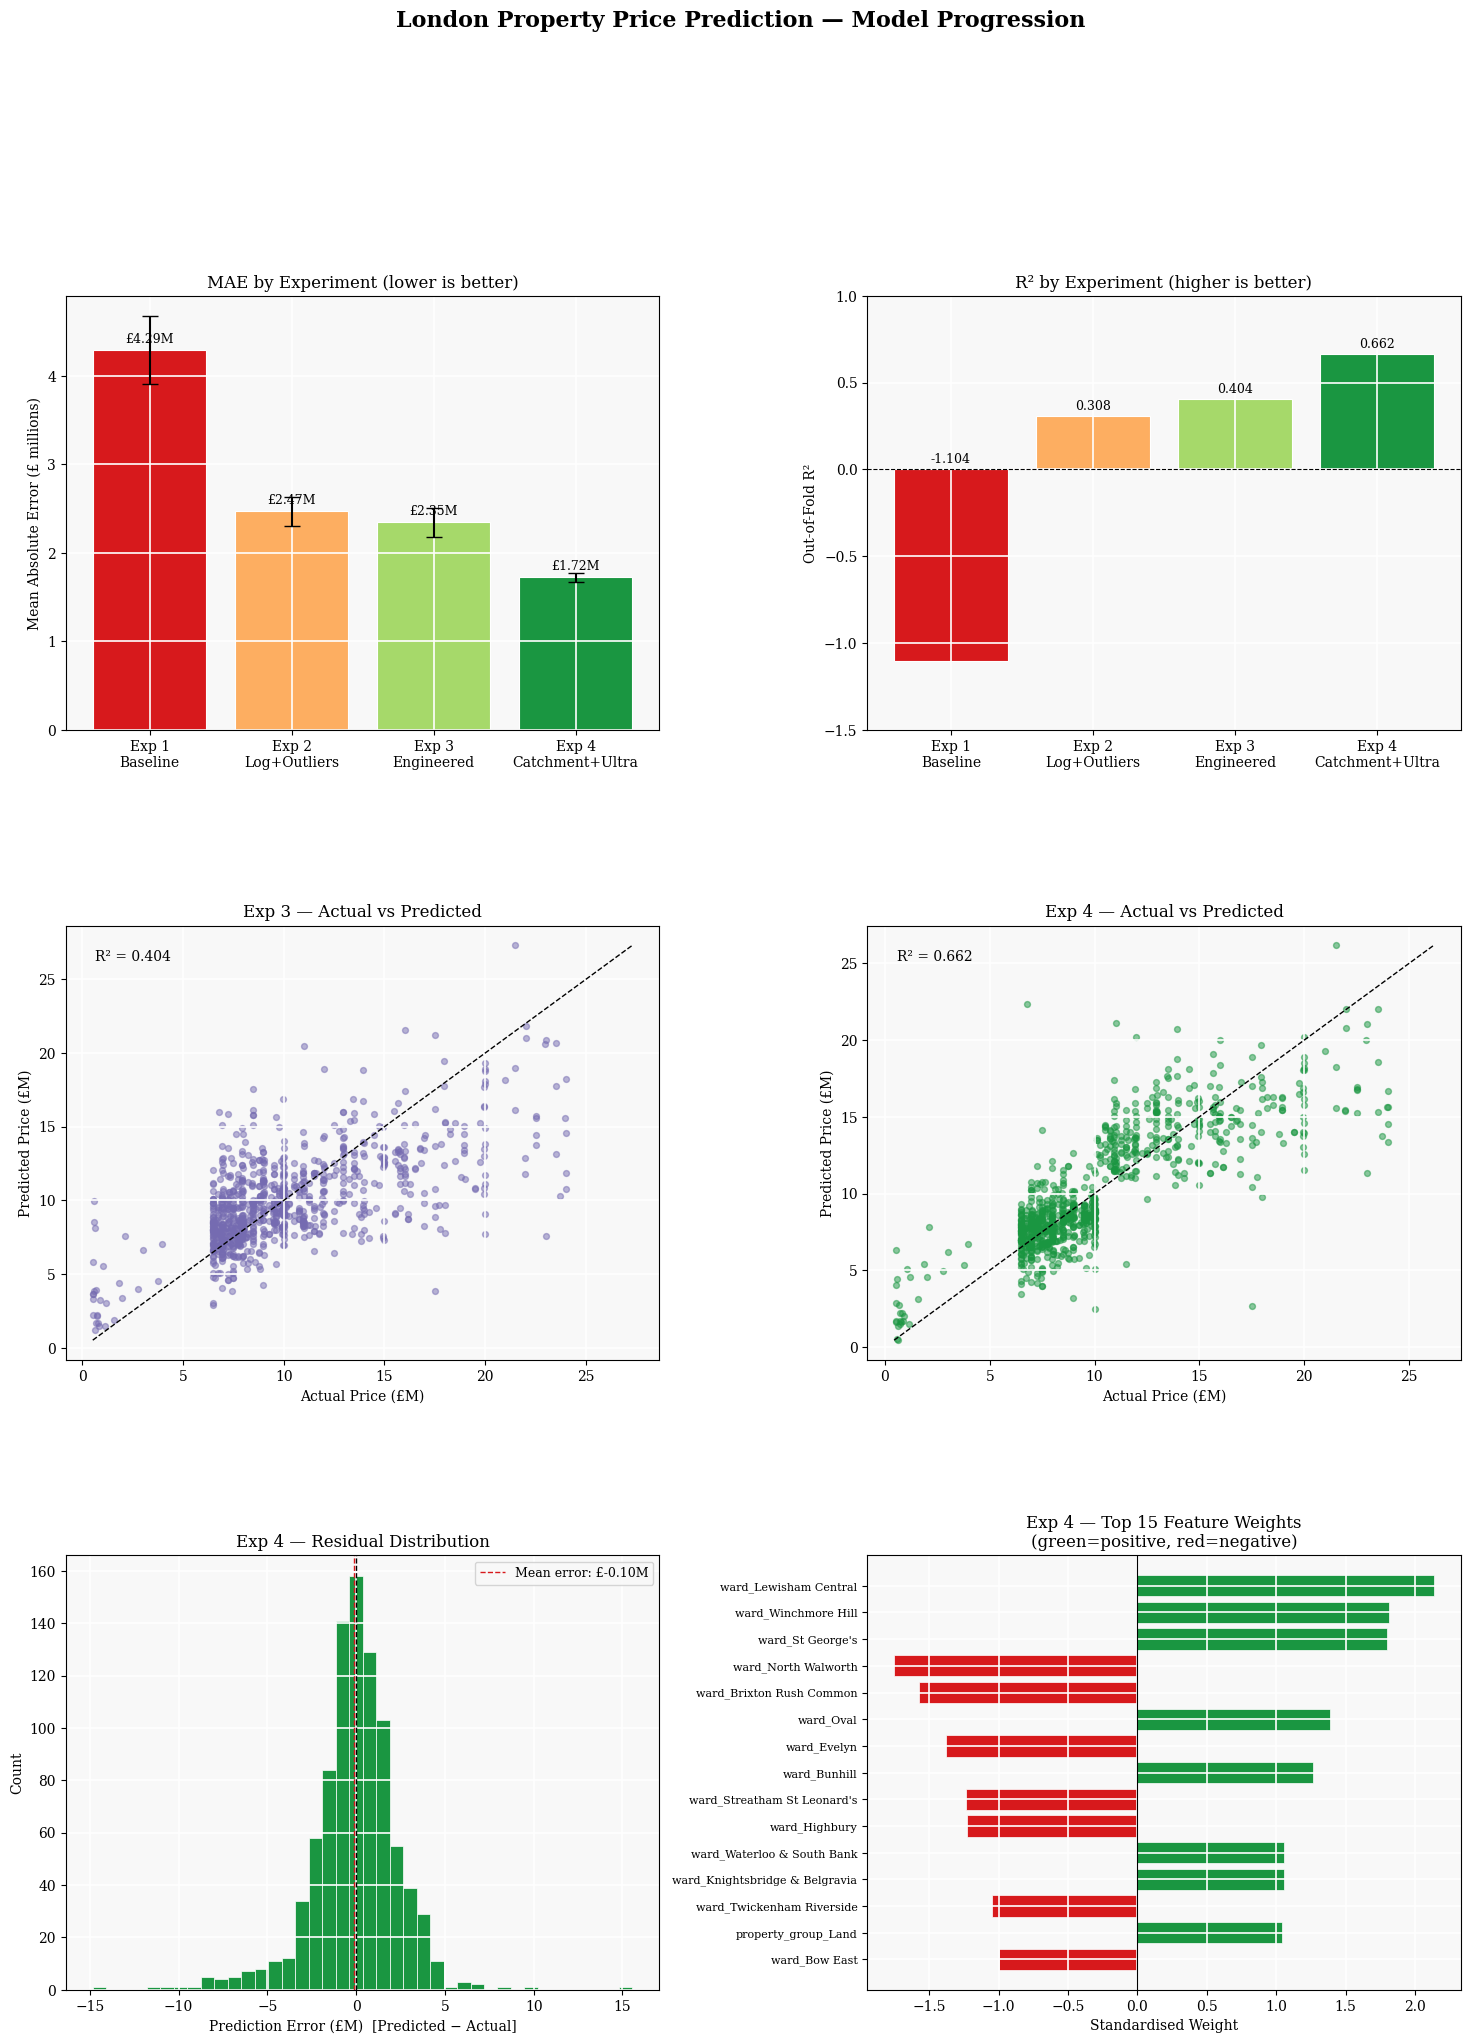

In [18]:
comparison = pd.DataFrame(all_results).sort_values("OOF_R2", ascending=False)
exp_labels = ["Exp 1\nBaseline", "Exp 2\nLog+Outliers", "Exp 3\nEngineered", "Exp 4\nCatchment+Ultra"]
colors = ["#d7191c", "#fdae61", "#a6d96a", "#1a9641"]

fig = plt.figure(figsize=(18, 22))
fig.suptitle("London Property Price Prediction — Model Progression", fontsize=16, fontweight="bold", y=1.01)
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.45, wspace=0.35)


ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(exp_labels, 
               [r["MAE"] / 1e6 for r in all_results],
               yerr=[r["MAE_std"] / 1e6 for r in all_results],
               color=colors, capsize=6, edgecolor="white", linewidth=0.8)
ax1.set_ylabel("Mean Absolute Error (£ millions)")
ax1.set_title("MAE by Experiment (lower is better)")
for bar, r in zip(bars, all_results):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'£{r["MAE"]/1e6:.2f}M', ha='center', va='bottom', fontsize=9)

ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(exp_labels,
                [r["OOF_R2"] for r in all_results],
                color=colors, edgecolor="white", linewidth=0.8)
ax2.set_ylabel("Out-of-Fold R²")
ax2.set_title("R² by Experiment (higher is better)")
ax2.set_ylim(-1.5, 1.0)
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
for bar, r in zip(bars2, all_results):
    ypos = max(bar.get_height(), 0) + 0.02
    ax2.text(bar.get_x() + bar.get_width()/2, ypos,
             f'{r["OOF_R2"]:.3f}', ha='center', va='bottom', fontsize=9)

ax3 = fig.add_subplot(gs[1, 0])
y_true3 = d3["y_test_price"].flatten() / 1e6
y_pred3 = p3.flatten() / 1e6
ax3.scatter(y_true3, y_pred3, alpha=0.5, s=18, color="#756bb1")
lims = [min(y_true3.min(), y_pred3.min()), max(y_true3.max(), y_pred3.max())]
ax3.plot(lims, lims, 'k--', linewidth=1)
ax3.set_xlabel("Actual Price (£M)")
ax3.set_ylabel("Predicted Price (£M)")
ax3.set_title("Exp 3 — Actual vs Predicted")
r2_3 = r2_score(d3["y_test_price"].flatten(), p3.flatten())
ax3.text(0.05, 0.92, f'R² = {r2_3:.3f}', transform=ax3.transAxes, fontsize=10)

ax4 = fig.add_subplot(gs[1, 1])
y_true4 = d4["y_test_price"].flatten() / 1e6
y_pred4 = p4.flatten() / 1e6
ax4.scatter(y_true4, y_pred4, alpha=0.5, s=18, color="#1a9641")
lims = [min(y_true4.min(), y_pred4.min()), max(y_true4.max(), y_pred4.max())]
ax4.plot(lims, lims, 'k--', linewidth=1)
ax4.set_xlabel("Actual Price (£M)")
ax4.set_ylabel("Predicted Price (£M)")
ax4.set_title("Exp 4 — Actual vs Predicted")
r2_4 = r2_score(d4["y_test_price"].flatten(), p4.flatten())
ax4.text(0.05, 0.92, f'R² = {r2_4:.3f}', transform=ax4.transAxes, fontsize=10)

ax5 = fig.add_subplot(gs[2, 0])
errors4 = (y_pred4 - y_true4)
ax5.hist(errors4, bins=40, color="#1a9641", edgecolor="white", linewidth=0.5)
ax5.axvline(0, color="black", linestyle="--", linewidth=1)
ax5.axvline(errors4.mean(), color="#d7191c", linestyle="--", linewidth=1,
            label=f'Mean error: £{errors4.mean():.2f}M')
ax5.set_xlabel("Prediction Error (£M)  [Predicted − Actual]")
ax5.set_ylabel("Count")
ax5.set_title("Exp 4 — Residual Distribution")
ax5.legend(fontsize=9)

ax6 = fig.add_subplot(gs[2, 1])

# Get feature names from last fold to match last model
data4 = build_modeling_data(
    df,
    numeric_features=catchment_numeric,
    categorical_features=full_categorical,
    use_outlier_removal=True,
    add_engineered_features=True
)
kf_temp = KFold(n_splits=5, shuffle=True, random_state=42)
splits = list(kf_temp.split(data4))
train_idx, val_idx = splits[-1]
last_fold_data = prepare_fold_data(
    data=data4,
    train_idx=train_idx,
    val_idx=val_idx,
    numeric_features=catchment_numeric,
    categorical_features=full_categorical,
    use_log_price=True
)

last_model = m4[-1]
weights = last_model.linear.weight.detach().numpy().flatten()
feature_names = last_fold_data["feature_names"]

importance_df = pd.DataFrame({"feature": feature_names, "weight": weights})
importance_df["abs_weight"] = importance_df["weight"].abs()
importance_df = importance_df.nlargest(15, "abs_weight")
importance_df = importance_df.sort_values("abs_weight")

bar_colors = ["#d7191c" if w < 0 else "#1a9641" for w in importance_df["weight"]]
ax6.barh(importance_df["feature"], importance_df["weight"],
         color=bar_colors, edgecolor="white", linewidth=0.5)
ax6.axvline(0, color="black", linewidth=0.8)
ax6.set_xlabel("Standardised Weight")
ax6.set_title("Exp 4 — Top 15 Feature Weights\n(green=positive, red=negative)")
ax6.tick_params(axis='y', labelsize=8)

plt.savefig("model_results.png", dpi=150, bbox_inches="tight")
plt.show()

In [24]:
comparison = pd.DataFrame(all_results)
comparison = comparison.sort_values("MAE")

comparison[
    [
        "model",
        "num_features",
        "MAE",
        "MAE_std",
        "RMSE",
        "RMSE_std",
        "R2",
        "R2_std",
        "OOF_MAE",
        "OOF_RMSE",
        "OOF_R2"
    ]
]

,model,num_features,MAE,MAE_std,RMSE,RMSE_std,R2,R2_std,OOF_MAE,OOF_RMSE,OOF_R2
3,Exp 4 — Catchment + ultra-luxury flag,118,1.723964e+06,51667.077809,2.451244e+06,1.755005e+05,0.657345,0.059890,1.724002e+06,2.456139e+06,0.662224
2,Exp 3 — Engineered features,107,2.345747e+06,160859.235464,3.258931e+06,1.725910e+05,0.398204,0.048935,2.345853e+06,3.262731e+06,0.403947
1,Exp 2 — Log price + outlier removal,100,2.469376e+06,161095.066759,3.507093e+06,2.564920e+05,0.302535,0.082060,2.469425e+06,3.514507e+06,0.308406
0,"Exp 1 — Baseline (raw price, basic features)",46,4.290703e+06,379298.147287,8.896750e+06,5.238948e+06,-1.113086,2.564820,4.291065e+06,1.006169e+07,-1.104009


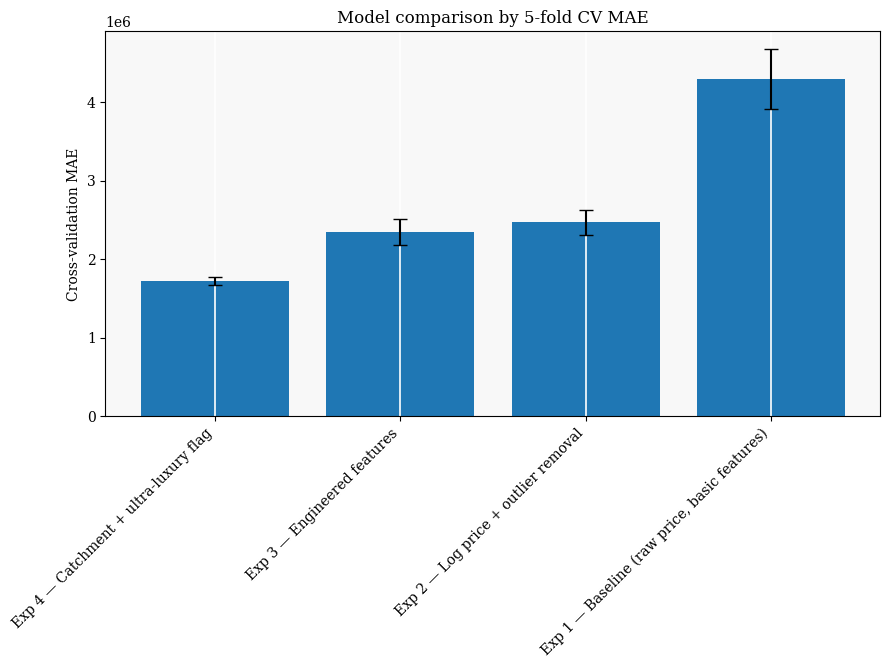

In [21]:
plt.figure(figsize=(10, 5))

plt.bar(
    comparison["model"],
    comparison["MAE"],
    yerr=comparison["MAE_std"],
    capsize=5
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Cross-validation MAE")
plt.title("Model comparison by 5-fold CV MAE")
plt.grid(axis="y")

plt.show()

In [23]:
summary = pd.DataFrame([{
    "Experiment": r["model"],
    "Features": r["num_features"],
    "MAE (£M)": round(r["MAE"] / 1e6, 3),
    "RMSE (£M)": round(r["RMSE"] / 1e6, 3),
    "R²": round(r["OOF_R2"], 4),
} for r in all_results])

print(summary.to_string(index=False))

                                  Experiment  Features  MAE (£M)  RMSE (£M)      R²
Exp 1 — Baseline (raw price, basic features)        46     4.291      8.897 -1.1040
         Exp 2 — Log price + outlier removal       100     2.469      3.507  0.3084
                 Exp 3 — Engineered features       107     2.346      3.259  0.4039
       Exp 4 — Catchment + ultra-luxury flag       118     1.724      2.451  0.6622
